In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/wine.csv')
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [5]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [9]:
df.shape

(178, 14)

In [10]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


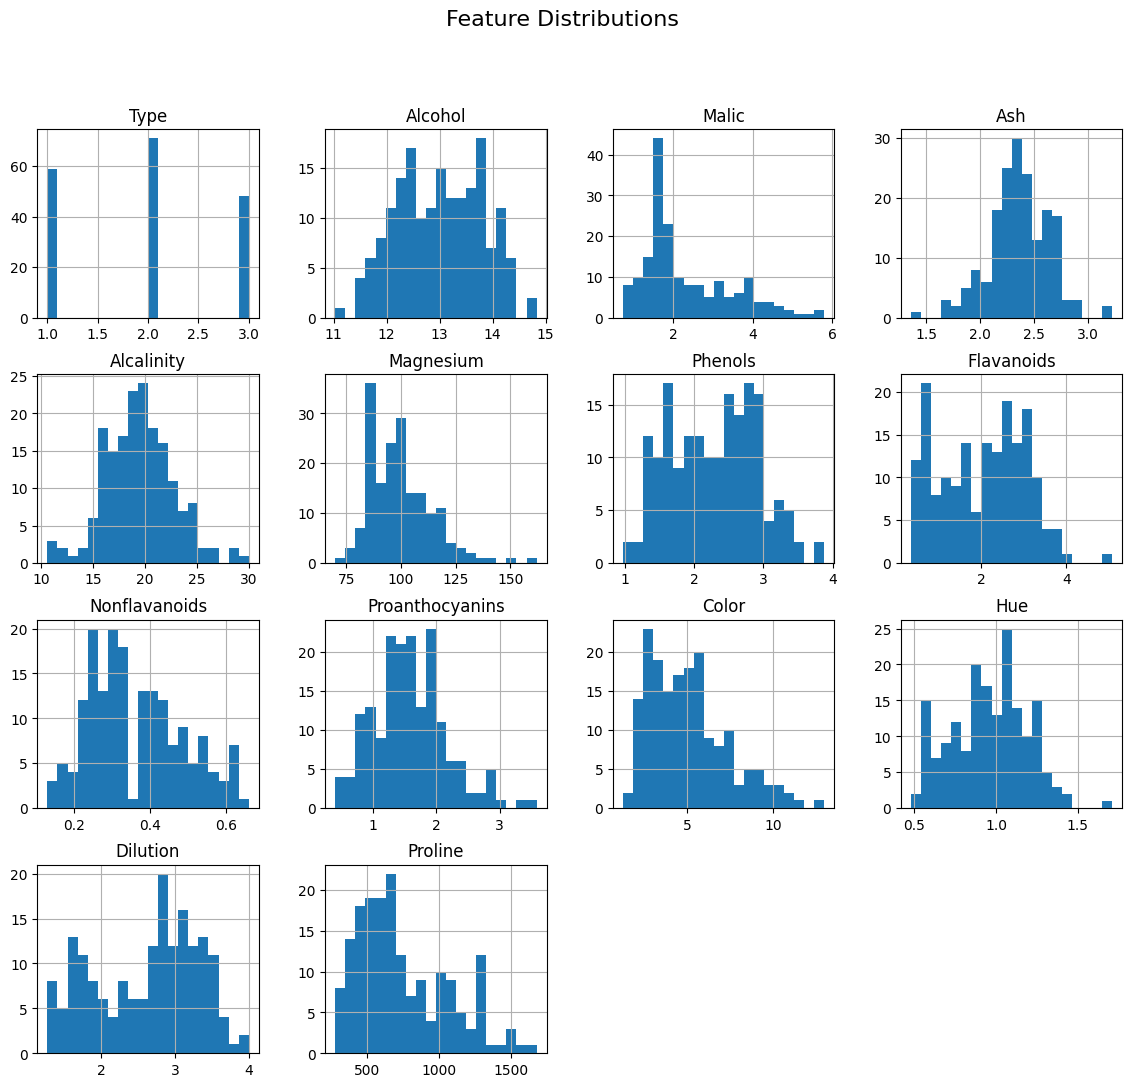

In [11]:
df.hist(figsize=(14,12), bins=20)
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()


<Axes: >

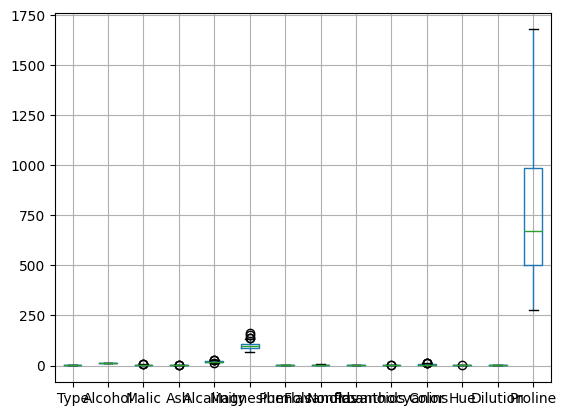

In [12]:
df.boxplot()

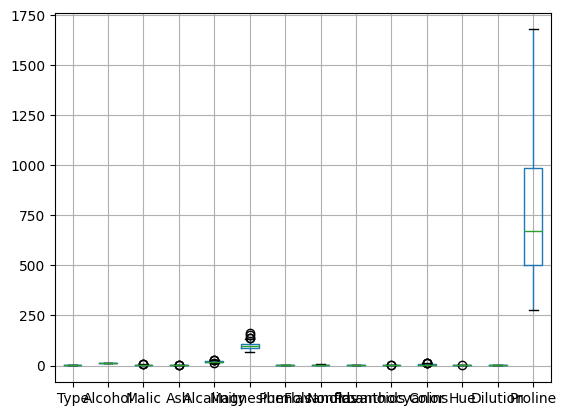

In [13]:
#Checking outliers
df.boxplot()
plt.show()

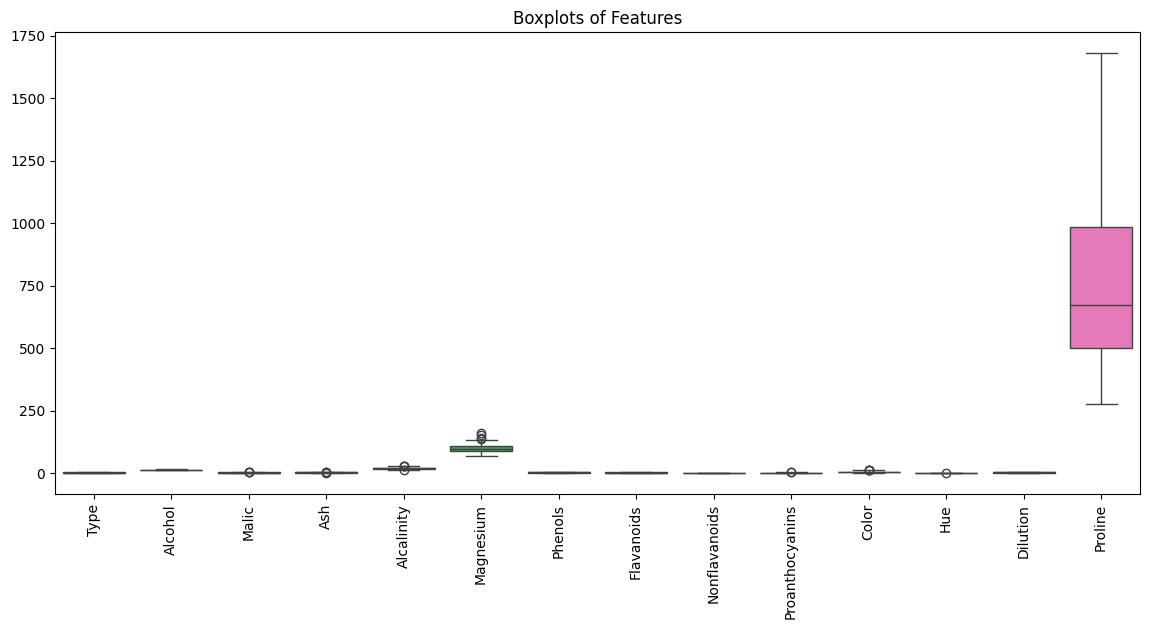

In [14]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplots of Features')
plt.show()

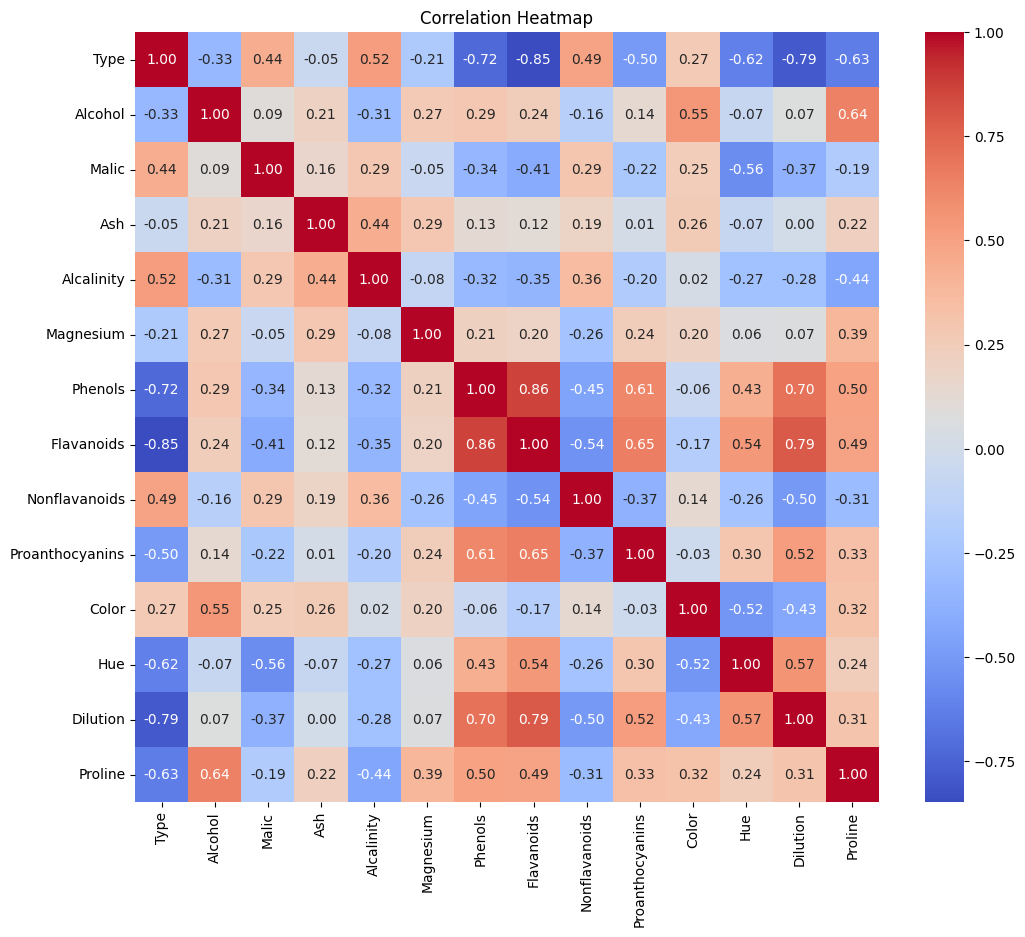

In [15]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [16]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print('\nMean after Scaling')
print(np.round(X_scaled.mean(axis=0), 2))

print('\nStandard Deviation after Scaling')
print(np.round(X_scaled.std(axis=0), 2))


Mean after Scaling
[ 0. -0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]

Standard Deviation after Scaling
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [17]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [20]:
# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print('\nExplained Variance Ratio')
print(explained_variance)



Explained Variance Ratio
[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615 0.01613203 0.01205691
 0.00925458 0.00412945]


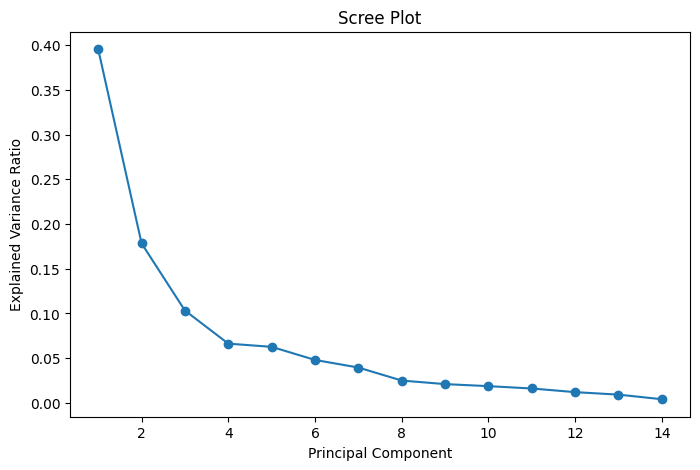

In [21]:
# Scree Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

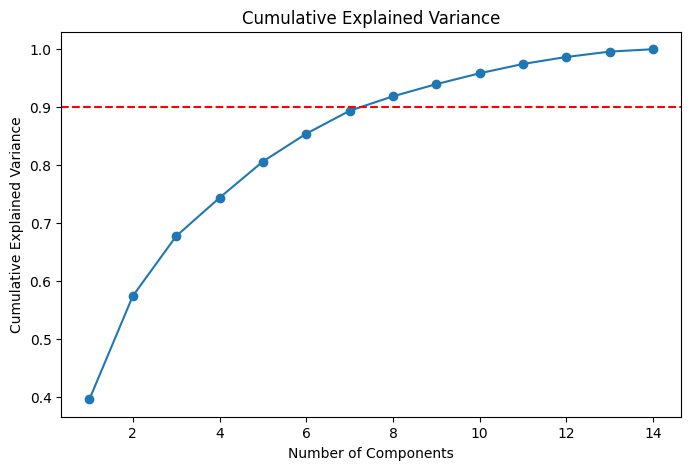

In [22]:
# Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')
plt.axhline(y=0.90, color='red', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.show()

In [23]:
# Select components explaining at least 90% variance
n_components = np.argmax(cumulative_variance >= 0.90) + 1

print('\nOptimal Number of Components:', n_components)


Optimal Number of Components: 8


In [24]:
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)

print('\nShape After PCA:', X_pca_final.shape)



Shape After PCA: (178, 8)


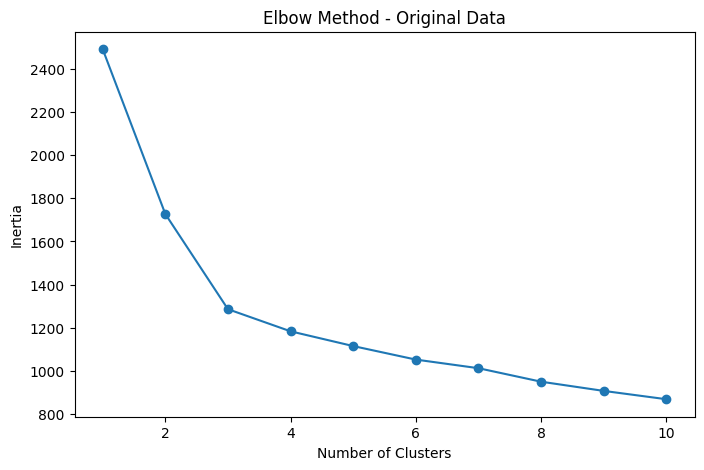

In [25]:

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Original Data')
plt.show()

In [26]:
# K-Means
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
original_labels = kmeans_original.fit_predict(X_scaled)


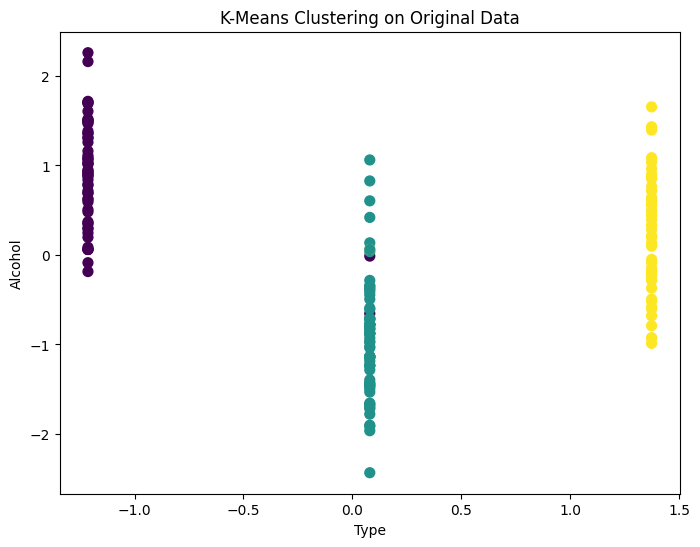

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0],
            X_scaled[:,1],
            c=original_labels,
            cmap='viridis',
            s=50)
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('K-Means Clustering on Original Data')
plt.show()

In [28]:
sil_original = silhouette_score(X_scaled, original_labels)
db_original = davies_bouldin_score(X_scaled, original_labels)

print('\nOriginal Data Silhouette Score :', round(sil_original, 4))
print('Original Data Davies-Bouldin   :', round(db_original, 4))



Original Data Silhouette Score : 0.3077
Original Data Davies-Bouldin   : 1.3164


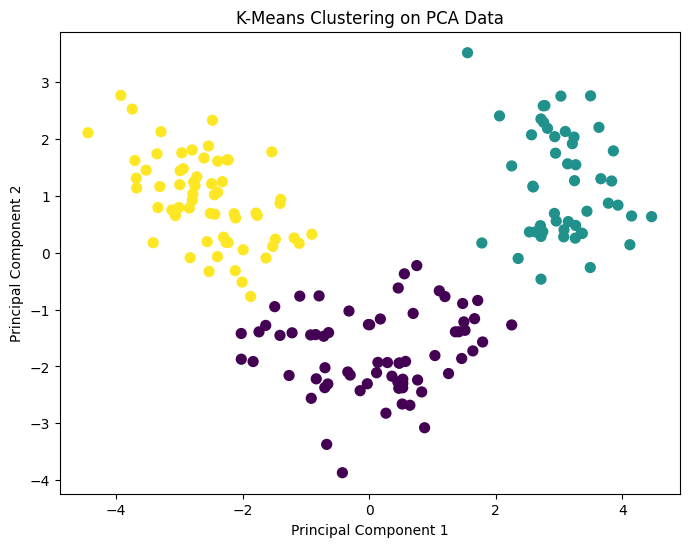

In [29]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_labels = kmeans_pca.fit_predict(X_pca_final)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_pca_final[:,0],
            X_pca_final[:,1],
            c=pca_labels,
            cmap='viridis',
            s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering on PCA Data')
plt.show()


In [30]:
# Evaluation
sil_pca = silhouette_score(X_pca_final, pca_labels)
db_pca = davies_bouldin_score(X_pca_final, pca_labels)

print('\nPCA Data Silhouette Score :', round(sil_pca, 4))
print('PCA Data Davies-Bouldin   :', round(db_pca, 4))




PCA Data Silhouette Score : 0.3402
PCA Data Davies-Bouldin   : 1.1903


In [31]:
comparison = pd.DataFrame({
    'Dataset': ['Original Data', 'PCA Data'],
    'Silhouette Score': [sil_original, sil_pca],
    'Davies-Bouldin Index': [db_original, db_pca]
})

print('\nClustering Comparison')
print(comparison)


Clustering Comparison
         Dataset  Silhouette Score  Davies-Bouldin Index
0  Original Data          0.307736              1.316396
1       PCA Data          0.340243              1.190304


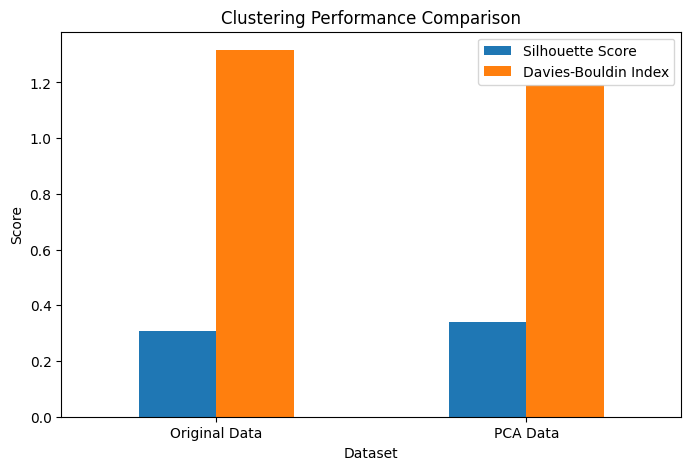

In [32]:
# Comparison Plot
comparison.set_index('Dataset').plot(kind='bar', figsize=(8,5))
plt.title('Clustering Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [37]:
## Conclusion and Insights

In [35]:
#Conclusion
if sil_pca > sil_original:
    print('PCA improved clustering performance.')
else:
    print('Original data performed better.')

if db_pca < db_original:
    print('PCA produced more compact and well-separated clusters.')
else:
    print('Original data produced more compact and well-separated clusters.')

print('\nPCA reduces dimensionality and noise,')
print('improves visualization, and can improve clustering quality.')
print('Always compare clustering metrics before choosing the final model.')

PCA improved clustering performance.
PCA produced more compact and well-separated clusters.

PCA reduces dimensionality and noise,
improves visualization, and can improve clustering quality.
Always compare clustering metrics before choosing the final model.
